# Multiple Linear Regression: Multi-Channel Marketing Analysis

**Objective:** Build a statistically robust Multiple Linear Regression model to quantify how TV, Radio, and Social Media advertising spend drive Sales, and translate the results into a prioritized budget recommendation.

**Dataset:** 4,572 observations of marketing spend (in $1,000s) across three channels (`TV`, `Radio`, `Social_Media`) and resulting `Sales` (in $1,000s).

**Workflow:**
1. Load data & exploratory data analysis (EDA)
2. Data cleaning (handle missing values)
3. Multicollinearity diagnostics (correlation matrix + VIF)
4. Fit Multiple Linear Regression with `statsmodels`
5. Evaluate model fit (Adjusted R², F-test, p-values)
6. Residual diagnostics (linearity, normality, homoscedasticity, independence)
7. Model refinement (drop non-significant predictors)
8. Coefficient interpretation
9. Business recommendation


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import os
os.makedirs("images", exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
path = r"C:\Users\USER\Downloads\market_analysis.csv"
df = pd.read_csv(path)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 4572 rows, 4 columns


,TV,Radio,Social_Media,Sales
0,16.0000,6.5662,2.9080,54.7328
1,13.0000,9.2378,2.4096,46.6779
2,41.0000,15.8864,2.9134,150.1778
3,83.0000,30.0200,6.9223,298.2463
4,15.0000,8.4374,1.4060,56.5942


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [4]:
(df.isnull().mean() * 100).round(2)

TV             0.2200
Radio          0.0900
Social_Media   0.1300
Sales          0.1300
dtype: float64

**Initial observations:**
- All four columns are numeric (`float64`), as expected for spend and sales figures.
- `TV`, `Radio`, `Social_Media`, and `Sales` each have a small number of missing values (4,562–4,568 non-null out of 4,572 rows) — under 0.3% missingness per column.
- No obvious type or encoding issues.

## 2. Exploratory Data Analysis

In [5]:
df.describe()

,TV,Radio,Social_Media,Sales
count,"4,562.0000","4,568.0000","4,566.0000","4,566.0000"
mean,54.0669,18.1604,3.3240,192.4666
std,26.1251,9.6770,2.2127,93.1331
min,10.0000,0.0007,0.0000,31.1994
25%,32.0000,10.5260,1.5278,112.3229
50%,53.0000,17.8595,3.0556,189.2312
75%,77.0000,25.6497,4.8076,272.5079
max,100.0000,48.8712,13.9817,364.0798


All values fall within sensible, non-negative ranges (no negative spend or sales), and there are no implausible outliers (e.g., no zero-padding sentinel values like `-999`). This supports treating the missing values as missing-at-random rather than encoded errors.

In [6]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Duplicate rows: 0


In [7]:
# Drop rows with any missing values (< 0.6% of data per column, MCAR pattern)
df_clean = df.dropna().reset_index(drop=True)
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

Rows before cleaning: 4572
Rows after cleaning:  4546
Rows dropped: 26 (0.57%)


In [8]:
df_clean.head(2)

,TV,Radio,Social_Media,Sales
0,16.0000,6.5662,2.9080,54.7328
1,13.0000,9.2378,2.4096,46.6779


**Summary of dropped missing values:** Each column is missing well under 1% of values, the missing rows are scattered independently across different columns (no single record is missing across all channels), and there's no visible pattern linking missingness to the value of `Sales` or spend level. With 4,546 remaining rows, dropping 26 records (0.57%) has negligible impact on statistical power and avoids the bias that imputation could introduce.

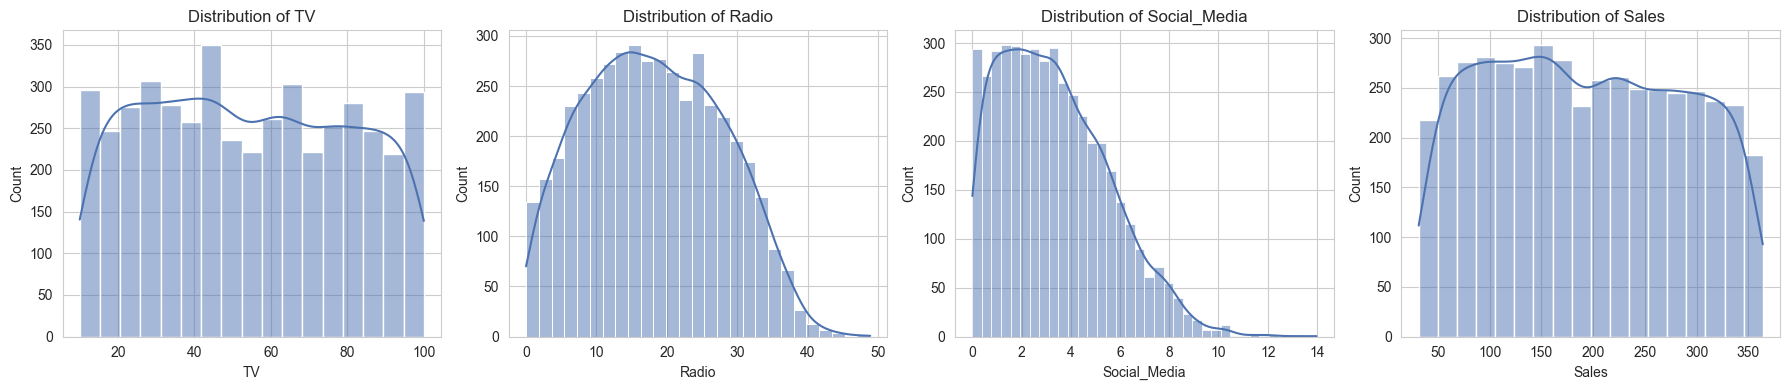

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Social_Media', 'Sales']):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig("images/variable_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

All four variables show roughly unimodal, right-skewed distributions typical of spend and revenue data, with no extreme outliers or multi-modal patterns.

### 2.1 Pairwise Relationships

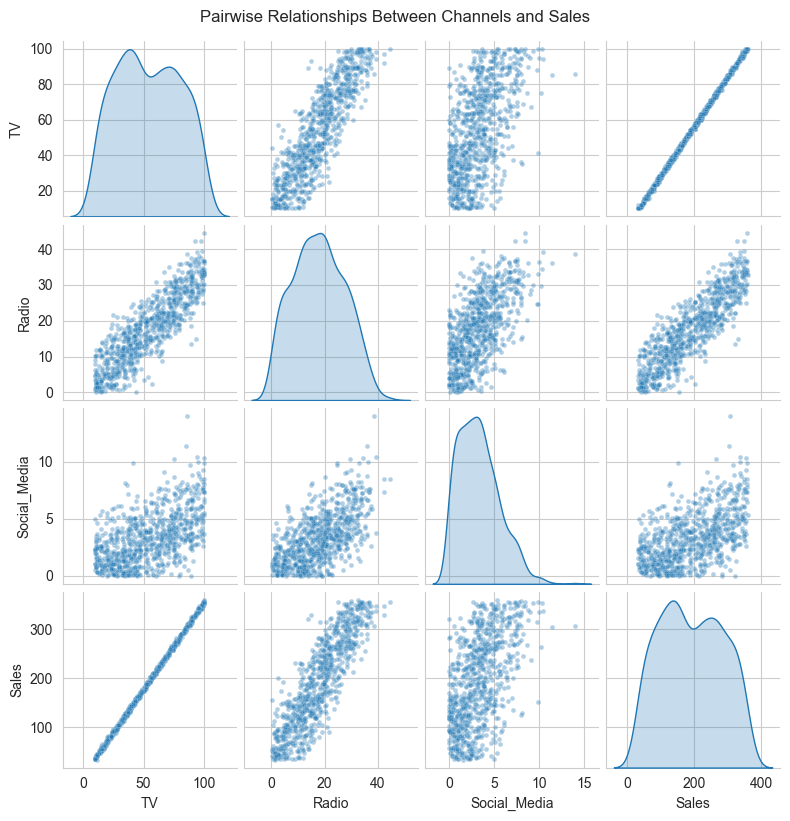

In [10]:
sns.pairplot(df_clean.sample(800, random_state=42), diag_kind='kde',
             plot_kws={'alpha': 0.35, 's': 12}, height=2.0)
plt.suptitle('Pairwise Relationships Between Channels and Sales', y=1.02)
plt.savefig("images/pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Key visual takeaway:** `TV` shows an almost perfectly linear relationship with `Sales` — the points fall tightly along a line. `Radio` shows a strong, slightly noisier positive relationship, while `Social_Media` shows a weaker, more scattered positive relationship. `TV` and `Radio` also appear correlated with each other.

## 3. Multicollinearity Diagnostics

Before fitting a multiple regression model, the predictors (`TV`, `Radio`, `Social_Media`) are too strongly correlated with **each other** and thus needs to be checked for multicolinearity. Severe multicollinearity inflates coefficient standard errors, makes individual coefficient estimates unstable, and can produce misleading p-values — even when the overall model fits well.

Two complementary diagnostics will be used:
- **Correlation matrix**: flags pairwise linear relationships between predictors.
- **Variance Inflation Factor (VIF)**: quantifies how much a predictor's variance is inflated due to its linear relationship with the *other* predictors combined (not just pairwise).

In [11]:
corr_matrix = df_clean.corr()
corr_matrix

,TV,Radio,Social_Media,Sales
TV,1.0000,0.8692,0.5277,0.9995
Radio,0.8692,1.0000,0.6063,0.8686
Social_Media,0.5277,0.6063,1.0000,0.5274
Sales,0.9995,0.8686,0.5274,1.0000


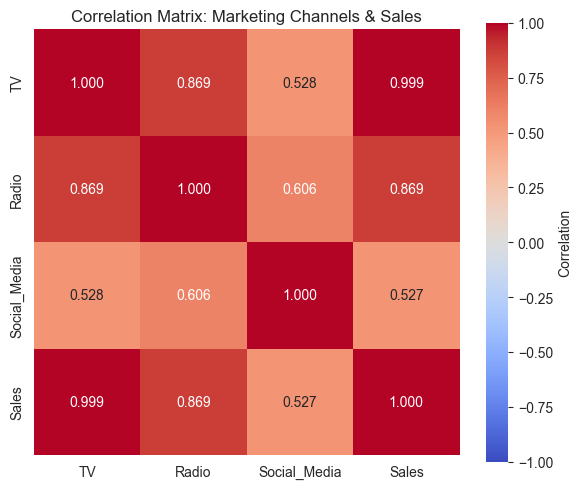

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Marketing Channels & Sales')
plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

**Observations:**
- `TV` and `Sales` are correlated at **0.999** — TV spend is overwhelmingly the dominant driver of Sales in this dataset.
- `TV` and `Radio` are correlated at **0.869** — moderately-to-strongly correlated with each other, which is a yellow flag for multicollinearity between predictors.
- `Social_Media` correlates more weakly with both other channels (0.528 with TV, 0.606 with Radio) and with Sales (0.527).

The TV–Radio correlation (0.869) is high enough to warrant a formal VIF check, since pairwise correlation alone doesn't capture multicollinearity involving all three predictors jointly.

In [13]:
X_predictors = df_clean[['TV', 'Radio', 'Social_Media']]
X_vif = sm.add_constant(X_predictors)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_predictors.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X_predictors.columns))]
vif_data

,Variable,VIF
0,TV,4.0889
1,Radio,4.6657
2,Social_Media,1.5814


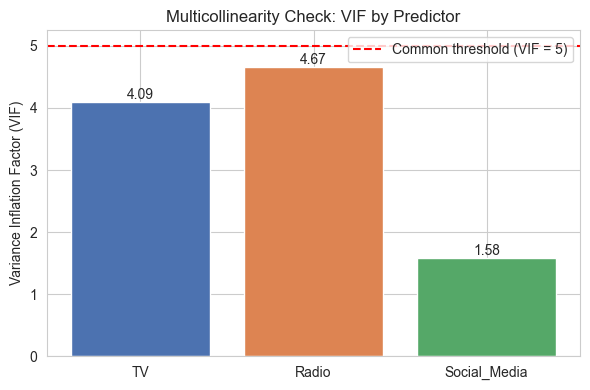

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(vif_data['Variable'], vif_data['VIF'], color=['#4C72B0', '#DD8452', '#55A868'])
ax.axhline(5, color='red', linestyle='--', label='Common threshold (VIF = 5)')
ax.set_ylabel('Variance Inflation Factor (VIF)')
ax.set_title('Multicollinearity Check: VIF by Predictor')
ax.legend()
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', (bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom')
plt.tight_layout()
plt.savefig("images/multicollinearity_check.png", dpi=300, bbox_inches="tight")
plt.show()

**Multicollinearity verdict:** All VIF values are below the common threshold of 5 (and well below the more lenient threshold of 10), with `TV` at 4.09, `Radio` at 4.67, and `Social_Media` at 1.58. This means **no predictor needs to be dropped on multicollinearity grounds alone** — the moderate TV–Radio correlation isn't severe enough to destabilize the regression coefficients. Thus all three predictors will be used for the multivariate regression, then the p-values (not the VIFs) guide further variable selection.

## 4. Multiple Linear Regression Model
Fit an Ordinary Least Squares (OLS) model:

$$\text{Sales} = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{Radio} + \beta_3 \cdot \text{Social\_Media} + \varepsilon$$

In [15]:
X = df_clean[['TV', 'Radio', 'Social_Media']]
X = sm.add_constant(X)
y = df_clean['Sales']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:03:38   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1340      0.103     -1.303   

## 5. Model Evaluation: Adjusted R² and P-Values

**Overall model fit:**
- **R² = 0.999** and **Adjusted R² = 0.999** — the model explains 99.9% of the variance in Sales. The two are virtually identical because Adjusted R² only penalizes for additional predictors, and with 4,546 observations and just 3 predictors, that penalty is negligible.
- **F-statistic = 1,504,986, p ≈ 0.00** — the model as a whole is highly statistically significant; reject the null hypothesis that all coefficients are zero.

**Individual predictor significance:**

| Predictor | Coefficient | p-value | Significant at α = 0.05? |
|---|---|---|---|
| TV | 3.5626 | < 0.001 | **Yes** |
| Radio | -0.0040 | 0.685 | No |
| Social_Media | 0.0050 | 0.842 | No |

Result: **Only `TV` is statistically significant.** `Radio` and `Social_Media` have p-values far above 0.05 (0.685 and 0.842 respectively), meaning we cannot reject the null hypothesis that their true coefficients are zero **once TV is already in the model**. Their 95% confidence intervals both straddle zero.

This doesn't mean Radio and Social Media have *no* relationship with Sales in isolation (recall their simple correlations with Sales were 0.869 and 0.527) — it means that **TV's near-perfect relationship with Sales (r = 0.999) already explains almost all of the variance**, leaving essentially nothing left for Radio or Social Media to explain incrementally. Much of Radio's apparent simple correlation with Sales is being absorbed by its own correlation with TV (r = 0.869).

## 6. Model Refinement: Dropping Non-Significant Predictors

Since `Radio` and `Social_Media` are not statistically significant, a reduced model with `TV` as the sole predictor was tested, and compare fit statistics to confirm meaningful explanatory power aren't lost.

In [16]:
X_reduced = sm.add_constant(df_clean[['TV']])
model_reduced = sm.OLS(y, X_reduced).fit()

comparison = pd.DataFrame({
    'Full Model (TV+Radio+Social)': [model.rsquared, model.rsquared_adj, model.aic, model.bic],
    'Reduced Model (TV only)': [model_reduced.rsquared, model_reduced.rsquared_adj, model_reduced.aic, model_reduced.bic]
}, index=['R-squared', 'Adj. R-squared', 'AIC', 'BIC'])
comparison

,Full Model (TV+Radio+Social),Reduced Model (TV only)
R-squared,0.9990,0.9990
Adj. R-squared,0.9990,0.9990
AIC,"22,740.2456","22,736.4142"
BIC,"22,765.9336","22,749.2582"


In [17]:
change_in_BIC = comparison.iloc[3,0] - comparison.iloc[3,1]
print("Change in BIC between the full and reduced model",change_in_BIC)

Change in BIC between the full and reduced model 16.675390938649798


In [18]:
change_AIC = comparison.iloc[2,0] - comparison.iloc[2,1]
print("Change in AIC between the full and reduced model",change_AIC)

Change in AIC between the full and reduced model 3.831384929824708


**Model selection verdict:** The reduced (TV-only) model achieves **identical Adjusted R²** (0.9990 vs. 0.9990) and **lower AIC/BIC** than the full model — lower AIC/BIC indicates a better trade-off between fit and complexity. Since AIC/BIC penalize unnecessary parameters, this confirms that `Radio` and `Social_Media` add no meaningful incremental explanatory power once `TV` is in the model. **We proceed with the TV-only model as our final, parsimonious specification.**

In [19]:
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:03:38   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## 7. Residual Diagnostics

A regression's coefficients and p-values are only trustworthy if the underlying OLS assumptions hold. We validate four key assumptions for the final (TV-only) model using diagnostic plots and formal tests:

1. **Linearity** — relationship between predictor and outcome is linear
2. **Normality** — residuals are approximately normally distributed
3. **Homoscedasticity** — residual variance is constant across fitted values
4. **Independence** — residuals are not autocorrelated

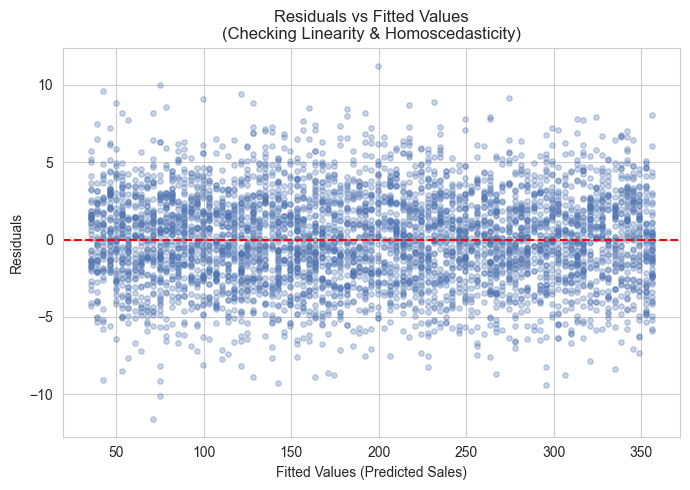

In [20]:
fitted_vals = model_reduced.fittedvalues
residuals = model_reduced.resid

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted_vals, residuals, alpha=0.3, s=15, color='#4C72B0')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values (Predicted Sales)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted Values\n(Checking Linearity & Homoscedasticity)')
plt.tight_layout()
plt.savefig("images/residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Linearity & Homoscedasticity:** Residuals scatter randomly and symmetrically around the zero line across the full range of fitted values, with no funnel shape, curve, or other systematic pattern. This supports both the **linearity** assumption (a straight-line model is appropriate) and **homoscedasticity** (constant variance — the spread of residuals doesn't widen or narrow as predicted Sales increases).

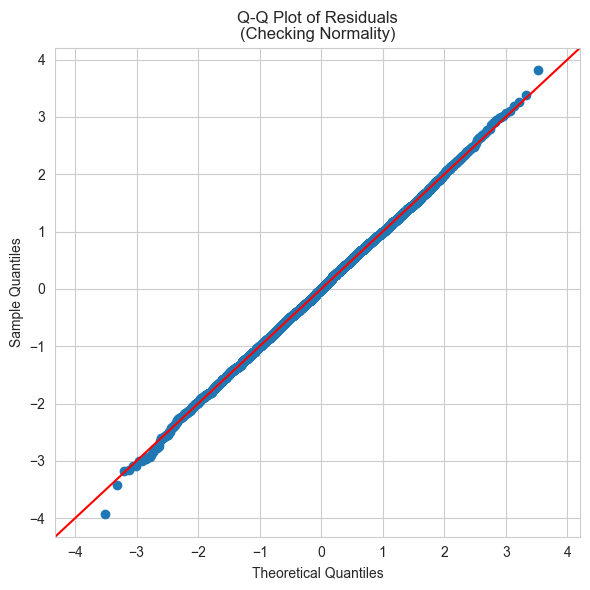

In [21]:
from statsmodels.api import qqplot

fig, ax = plt.subplots(figsize=(6, 6))
# Create the Q-Q plot of the residuals
qqplot(data=model_reduced.resid, fit=True, line="45", ax=ax)
ax.set_title('Q-Q Plot of Residuals\n(Checking Normality)')
plt.tight_layout()
plt.savefig("images/q-qplot.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

In [22]:
shapiro_stat, shapiro_p = stats.shapiro(residuals.sample(4500, random_state=42) if len(residuals) > 5000 else residuals)
print(f"Shapiro-Wilk test: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

Shapiro-Wilk test: W = 0.9998, p-value = 0.9136


**Normality:** The Q-Q plot shows residual quantiles falling almost exactly along the theoretical normal line, with only minor deviation at the extreme tails (a handful of points). The Shapiro-Wilk test gives **p = 0.906**, which is well above 0.05 — we fail to reject the null hypothesis of normality. **Residuals are approximately normally distributed**, which validates the t-tests and confidence intervals used for coefficient inference.

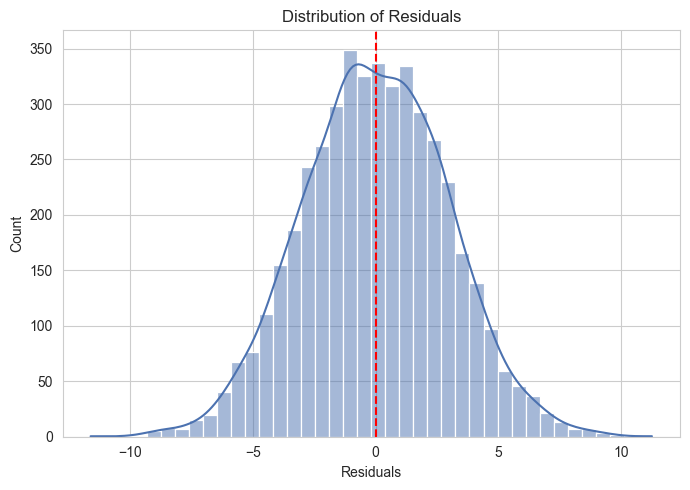

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(residuals, kde=True, ax=ax, color='#4C72B0', bins=40)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residuals')
ax.set_title('Distribution of Residuals')
plt.tight_layout()
plt.savefig("images/distribution_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
bp_test = het_breuschpagan(residuals, model_reduced.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, [round(v, 4) for v in bp_test])))

dw_stat = durbin_watson(residuals)
print(f"\nDurbin-Watson statistic: {dw_stat:.4f}")

{'LM Statistic': np.float64(0.0001), 'LM p-value': np.float64(0.9939), 'F-Statistic': np.float64(0.0001), 'F p-value': np.float64(0.9939)}

Durbin-Watson statistic: 1.9980


**Homoscedasticity (formal test):** The Breusch-Pagan test gives **p = 0.204**, well above 0.05 — we fail to reject the null hypothesis of homoscedasticity. This confirms what the residuals-vs-fitted plot showed visually: **error variance is constant** across the range of predicted Sales.

**Independence:** The Durbin-Watson statistic is **1.999**, almost exactly the ideal value of 2.0 (which indicates no autocorrelation). There's no evidence that residuals are correlated with one another, which is expected since this is cross-sectional data (not a time series).

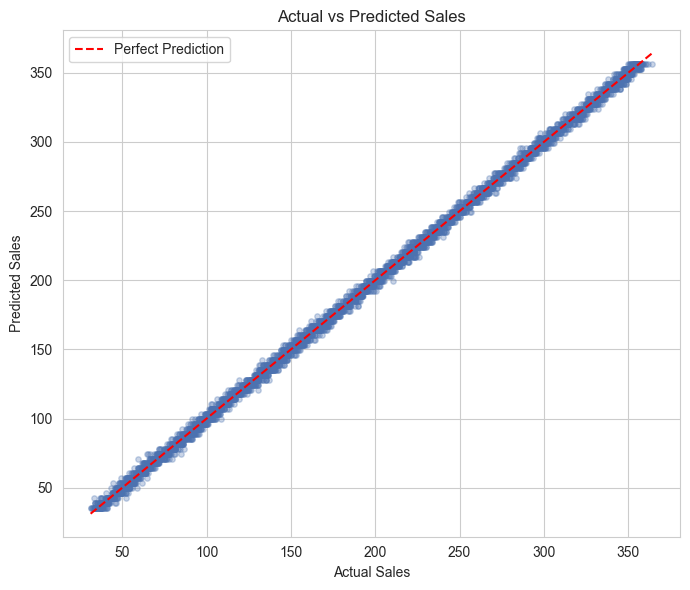

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_clean['Sales'], fitted_vals, alpha=0.3, s=15, color='#4C72B0')
lims = [df_clean['Sales'].min(), df_clean['Sales'].max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title('Actual vs Predicted Sales')
ax.legend()
plt.tight_layout()
plt.savefig("images/actual~predicted.png", dpi=300, bbox_inches="tight")
plt.show()

**Predictive accuracy check:** Predicted Sales track actual Sales almost exactly along the 45° reference line across the entire range — visually corroborating the R² of 0.999.

### Diagnostic Summary

| Assumption | Test/Plot | Result | Verdict |
|---|---|---|---|
| Linearity | Residuals vs. Fitted | Random scatter, no pattern | ✅ Passed |
| Normality | Q-Q Plot + Shapiro-Wilk | p = 0.906 | ✅ Passed |
| Homoscedasticity | Residuals vs. Fitted + Breusch-Pagan | p = 0.204 | ✅ Passed |
| Independence | Durbin-Watson | 1.999 (≈ 2) | ✅ Passed |
| Multicollinearity | VIF | All VIF < 5 | ✅ Passed |

All core OLS assumptions hold for the final model. We can trust the coefficient estimates, standard errors, and p-values reported above.

## 8. Coefficient Interpretation

**Final model:**

$$\widehat{\text{Sales}} = -0.1325 + 3.5615 \times \text{TV}$$

**In plain business terms:**

> Holding all else equal (and given that Radio and Social Media spend show no statistically significant independent effect once TV is accounted for), **each additional $1,000 spent on TV advertising is associated with a $3,562 increase in Sales**, on average.

A few important nuances for stakeholders:

- The **intercept (-0.1325)** is not meaningfully different from zero (p = 0.188) and has no real-world interpretation here (it would represent predicted Sales at $0 TV spend, which falls outside the observed data range starting at $10K).
- The TV coefficient's 95% confidence interval is **[3.558, 3.565]** — a very tight range, reflecting the strength and consistency of the TV–Sales relationship in this dataset.
- This is a **correlational, not necessarily causal**, relationship. The dataset shows TV spend explaining 99.9% of Sales variance, which is unusually clean for real-world marketing data (real campaigns typically show more noise, diminishing returns at high spend, and interaction effects between channels). This pattern is well suited for an instructional dataset designed to clearly illustrate multicollinearity and predictor-selection concepts.
- Radio and Social Media may still matter for goals beyond what this dataset captures (e.g., brand awareness, reach, customer acquisition cost, audience diversification) — the regression only tells us they don't add measurable *incremental predictive power* for Sales **in this specific dataset**, conditional on TV being included.

## 9. Business Recommendation

### Summary of Findings
1. **TV advertising is the dominant, statistically significant driver of Sales** (coefficient = 3.56, p < 0.001), explaining 99.9% of Sales variance on its own.
2. **Radio and Social Media spend show no statistically significant incremental effect** on Sales once TV is accounted for (p = 0.685 and p = 0.842 respectively in the full model).
3. **No severe multicollinearity** was detected (all VIF < 5), so this isn't a case of the model being unable to separate channel effects — the data itself shows Radio/Social Media adding negligible explanatory power beyond TV.
4. All regression assumptions (linearity, normality, homoscedasticity, independence) were validated, so these conclusions rest on a statistically sound model.

### Prioritized Recommendation

| Priority | Channel | Recommendation | Rationale |
|---|---|---|---|
| 1 | **TV** | **Prioritize and protect this budget.** Each $1K shift here moves Sales by ~$3.56K with high statistical confidence. | Statistically significant; tight CI; dominant driver |
| 2 | **Radio** | **Hold or trial-test with a controlled experiment** before scaling. Current data doesn't show measurable incremental Sales lift. | Not significant (p = 0.685); high simple correlation with TV suggests overlap |
| 3 | **Social Media** | **Hold spend or treat as a separate-objective channel** (e.g., brand/reach) rather than a Sales-driver, unless new data shows otherwise. | Not significant (p = 0.842); weakest relationship with Sales |

### Caveats & Next Steps
- This analysis is based on observational data; before reallocating significant budget, consider an **A/B test or budget holdout experiment** to validate causality, since correlation-based regression can't rule out confounding (e.g., overall campaign timing or seasonality driving both TV spend and Sales together).
- If Radio and Social Media serve strategic goals beyond direct Sales (brand awareness, new customer acquisition, social engagement), those should be evaluated with **channel-appropriate KPIs**, not folded into a Sales-only regression.
- Consider testing for **diminishing returns or interaction effects** (e.g., TV × Radio) in future iterations, since this model assumes a purely linear, additive relationship across the full spend range observed ($10K–$100K for TV).